# Data Wrangling — Tiki E-commerce (2 bộ)

Nguồn: [Vietnamese Tiki E-commerce Dataset (Kaggle)](https://www.kaggle.com/datasets/michaelminhpham/vietnamese-tiki-e-commerce-dataset)

1. `vietnamese_tiki_products_men_shoes.csv` — giày nam  
2. `vietnamese_tiki_products_women_shoes.csv` — giày nữ  

Mục tiêu gốc của bộ dữ liệu: dự đoán `quantity_sold`.

Mỗi bước có **1 dòng mẫu**. Dòng `# TODO` em làm tương tự (đổi tên cột / file).

## Download data and explore

Luôn bắt đầu bằng **nhìn dữ liệu**, đừng nhảy vào `fillna`. Hỏi: bao nhiêu dòng? cột nào object? giá trị lạ (`...`, tab, rỗng)?

| Cột | Ý nghĩa |
|---|---|
| `id` | Mã sản phẩm Tiki |
| `name` | Tên sản phẩm |
| `description` | Mô tả (có thể rỗng / `...`) |
| `original_price` | Giá gốc (VND) |
| `price` | Giá hiện tại (VND) |
| `fulfillment_type` | Hình thức giao: `dropship`, `tiki_delivery`, `seller_delivery` |
| `brand` | Thương hiệu (nhiều `OEM`, đôi khi dính tab `\\tOEM`) |
| `review_count` | Số đánh giá |
| `rating_average` | Điểm trung bình (0–5; 0 thường = chưa có đánh giá) |
| `favourite_count` | Số lượt yêu thích |
| `pay_later` | Có trả sau hay không |
| `current_seller` | Tên shop |
| `date_created` | Số ngày từ lần cập nhật |
| `number_of_images` | Số ảnh |
| `vnd_cashback` | Số tiền hoàn (VND) |
| `has_video` | Có video hay không |
| `category` | Danh mục (`Root` = chưa gán danh mục rõ) |
| `quantity_sold` | Tổng số đã bán (biến mục tiêu) |

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

path_men = "tiki_data/vietnamese_tiki_products_men_shoes.csv"
path_women = "tiki_data/vietnamese_tiki_products_women_shoes.csv"

df_men = pd.read_csv(path_men)  # mẫu: đọc file nam
# TODO: đọc file nữ vào df_women (giống dòng trên, đổi path_women)
df_women = None

print("Men shoes:", df_men.shape)  # mẫu: in số dòng, số cột
# TODO: in shape của df_women

df_men.head()  # mẫu: 5 dòng đầu
# TODO: xem 5 dòng đầu df_women

Men shoes: (5745, 19)


,Unnamed: 0,id,name,description,original_price,price,fulfillment_type,brand,review_count,rating_average,favourite_count,pay_later,current_seller,date_created,number_of_images,vnd_cashback,has_video,category,quantity_sold
0,0,103682599,"D4 Dép Tổ Ong Đi Mưa, Đi Trong Nhà Nam Nữ Chất...","Dép Tổ Ong Đi Mưa, Đi Trong Nhà Nam Nữ ...",9900,9900,dropship,OEM,8,3.0,0,False,Rumyh Fashion Style,829,4,268,False,Root,106
1,1,176818958,DÉP TỔ ONG ĐEN NHỰA CAO SU DẺO LOẠI ĐẸP ĐỦ SIZ...,LƯU Ý : KHÁCH MUA TỪ 5 ĐÔI TRỞ LÊN SHOP...,10000,10000,dropship,OEM,0,0.0,0,False,Tổng kho đồ gia dụng QL,504,4,0,False,Root,17
2,2,119214657,dép tổ ong huyền thoại full size,Dép Làm Chất liệu cao su tổng hợp giúp ...,9900,9900,dropship,OEM,9,3.2,0,False,sumo98 store,752,6,0,False,Root,83
3,3,164789853,Dép tổ ong đi trong nhà dày mỏng các loại,THÔNG TIN SẢN PHẨM DÉP TỔ ONG CÁC LOẠ...,24999,24999,dropship,OEM,0,0.0,0,False,Giày dép Trường Hằng,564,3,0,False,Root,0
4,4,208440729,"Dép xốp QUAI NGANG đi trong nhà/Khách sạn/Spa,...","Dép xốp quai ngang, đi trong nhà/Khách ...",14200,14200,dropship,OEM,0,0.0,0,False,TT8695,277,9,0,False,Root,0


---
# Bộ 1 — Giày nam

## 1. Xử lý giá trị thiếu (Missing Values)

- Chuỗi rỗng / `...` / `"nan"` → `NaN`.
- `fulfillment_type`, `brand`: cột phân loại → **mode**.
- `description`: điền `""` (không xoá dòng).
- `quantity_sold`: biến mục tiêu → `.dropna(subset=["quantity_sold"])`.

In [22]:
df = df_men.copy()  # mẫu: làm việc trên bản sao

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])  # mẫu: xoá cột index thừa

# TODO: xoá trùng theo id rồi reset_index — gợi ý: drop_duplicates(subset=["id"])

for c in df.select_dtypes(include="object").columns:
    df[c] = df[c].astype(str).str.strip().replace({"nan": np.nan, "": np.nan, "...": np.nan})  # mẫu: cắt khoảng trắng 2 đầu
    # TODO: trong vòng for, replace {"nan": np.nan, "": np.nan, "...": np.nan} cho df[c]
df["brand"] = df["brand"].str.replace("\t", "", regex=False)  # mẫu: xoá tab trong brand

print(df.isnull().sum())  # mẫu: đếm missing trước xử lý

df["fulfillment_type"] = df["fulfillment_type"].fillna(df["fulfillment_type"].mode(dropna=True)[0]) 
# TODO: fillna mode cho cột brand (copy mẫu, đổi tên cột)
df["brand"] = df["brand"].fillna(df["brand"].mode(dropna=True)[0])  
# TODO: df["description"] fillna bằng ""
df["description"] = df["description"].fillna("")
# TODO: dropna subset=["quantity_sold"] rồi reset_index
df = df.dropna(subset=["quantity_sold"]).reset_index(drop=True)
# TODO: in lại isnull().sum() sau khi xử lý
print("\nThieu say du lieu sau khi xu ly:")
print(df.isnull().sum())

id                    0
name                  0
description         258
original_price        0
price                 0
fulfillment_type      1
brand                 0
review_count          0
rating_average        0
favourite_count       0
pay_later             0
current_seller        0
date_created          0
number_of_images      0
vnd_cashback          0
has_video             0
category              0
quantity_sold         0
dtype: int64

Thieu say du lieu sau khi xu ly:
id                  0
name                0
description         0
original_price      0
price               0
fulfillment_type    0
brand               0
review_count        0
rating_average      0
favourite_count     0
pay_later           0
current_seller      0
date_created        0
number_of_images    0
vnd_cashback        0
has_video           0
category            0
quantity_sold       0
dtype: int64


C:\Users\USER\AppData\Local\Temp\ipykernel_12916\790140023.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df.select_dtypes(include="object").columns:


## 2. Sửa định dạng dữ liệu (Correct Data Format)

In [23]:
print(df.dtypes)  # mẫu: xem kiểu hiện tại

df["price"] = df["price"].astype(int)  # mẫu: ép price về int
# TODO: ép original_price, quantity_sold, review_count về int (giống dòng trên)
df["original_price"] = df["original_price"].astype(int)
df["quantity_sold"] = df["quantity_sold"].astype(int)
df["review_count"] = df["review_count"].astype(int)
# TODO: ép rating_average về float
df["rating_average"] = df["rating_average"].astype(float)
# TODO: print dtypes các cột vừa ép
print(df[["price", "original_price", "quantity_sold", "review_count", "rating_average"]].dtypes)

id                    int64
name                    str
description             str
original_price        int64
price                 int64
fulfillment_type        str
brand                   str
review_count          int64
rating_average      float64
favourite_count       int64
pay_later              bool
current_seller          str
date_created          int64
number_of_images      int64
vnd_cashback          int64
has_video              bool
category                str
quantity_sold         int64
dtype: object
price               int64
original_price      int64
quantity_sold       int64
review_count        int64
rating_average    float64
dtype: object


## 3. Chuẩn hoá dữ liệu (Data Standardization)

Giá đang là **VND**. Đổi sang **nghìn đồng** cho dễ đọc, và tính **% giảm giá** so với giá gốc.

In [24]:
df["price_nghin"] = df["price"] / 1000  # mẫu: VND → nghìn đồng
# TODO: cột original_price_nghin = original_price / 1000
df["original_price_nghin"] = df["original_price"] / 1000
# TODO: cột discount_pct = (original_price - price) / original_price * 100
#       dùng np.where(original_price > 0, công_thức, 0)
df["discount_pct"] = np.where(df["original_price"] > 0, (df["original_price"] - df["price"]) / df["original_price"] * 100, 0)
df[["price", "price_nghin"]].head()  # mẫu: xem kết quả
# TODO: head thêm original_price và discount_pct
df[["original_price", "original_price_nghin", "discount_pct"]].head()

,original_price,original_price_nghin,discount_pct
0,9900,9.900,0.0
1,10000,10.000,0.0
2,9900,9.900,0.0
3,24999,24.999,0.0
4,14200,14.200,0.0


## 4. Chuẩn hoá phạm vi giá trị (Data Normalization)

`price` và `quantity_sold` lệch thang đo rất mạnh → `x / x.max()` về 0–1.

In [25]:
df["price_normalized"] = df["price"] / df["price"].max()  # mẫu: chia max → 0–1
# TODO: quantity_sold_normalized = quantity_sold / max
df["quantity_sold_normalized"] = df["quantity_sold"] / df["quantity_sold"].max()
# TODO: review_count_normalized = review_count / max
df["review_count_normalized"] = df["review_count"] / df["review_count"].max()
# TODO: head thêm quantity_sold và cột normalize tương ứng
df[["price", "price_normalized", "quantity_sold", "quantity_sold_normalized"]].head()

,price,price_normalized,quantity_sold,quantity_sold_normalized
0,9900,0.000673,106,0.019525
1,10000,0.000680,17,0.003131
2,9900,0.000673,83,0.015288
3,24999,0.001701,0,0.000000
4,14200,0.000966,0,0.000000


## 5. Phân nhóm (Binning)

Chia giá thành Low / Medium / High theo ngưỡng VND thực tế (không dùng min–max đều vì giá max rất lớn, hầu hết sản phẩm sẽ rơi vào Low).

price_binned
Medium    2862
Low       1855
High      1028
Name: count, dtype: int64


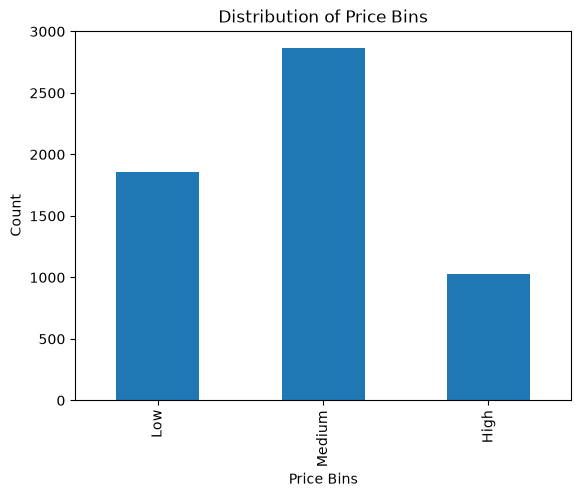

,price,price_binned
0,9900,Low
1,10000,Low
2,9900,Low
3,24999,Low
4,14200,Low


In [26]:
price_bins = [0, 100_000, 500_000, df["price"].max() + 1]  # mẫu: 3 khoảng giá

df["price_binned"] = pd.cut(
    df["price"], bins=price_bins, labels=["Low", "Medium", "High"], include_lowest=True
)  # mẫu: gán nhãn Low / Medium / High

print(df["price_binned"].value_counts())  # mẫu: đếm mỗi nhóm

# TODO: vẽ bar — gợi ý: df["price_binned"].value_counts().sort_index().plot(kind="bar")
df["price_binned"].value_counts().sort_index().plot(kind="bar")
# TODO: plt.xlabel / ylabel / title rồi plt.show()
plt.xlabel("Price Bins")
plt.ylabel("Count")
plt.title("Distribution of Price Bins")
plt.show()
df[["price", "price_binned"]].head()

## 6. Biến chỉ thị / Biến giả (Dummy Variable)

`fulfillment_type` (chữ) → mỗi hình thức giao một cột 0/1 bằng `pd.get_dummies()`, rồi xoá cột gốc.

In [27]:
dummy_ff = pd.get_dummies(df["fulfillment_type"], prefix="fulfillment", dtype=int)  # mẫu: cột 0/1

# TODO: gộp dummy vào df — pd.concat([df, dummy_ff], axis=1)
df = pd.concat([df, dummy_ff], axis=1)
# TODO: xoá cột gốc — df.drop(columns=["fulfillment_type"])
df = df.drop(columns=["fulfillment_type"])
df.head()  # mẫu: kiểm tra bảng

,id,name,description,original_price,price,brand,review_count,rating_average,favourite_count,pay_later,...,price_nghin,original_price_nghin,discount_pct,price_normalized,quantity_sold_normalized,review_count_normalized,price_binned,fulfillment_dropship,fulfillment_seller_delivery,fulfillment_tiki_delivery
0,103682599,"D4 Dép Tổ Ong Đi Mưa, Đi Trong Nhà Nam Nữ Chất...","Dép Tổ Ong Đi Mưa, Đi Trong Nhà Nam Nữ Chất Nh...",9900,9900,OEM,8,3.0,0,False,...,9.900,9.900,0.0,0.000673,0.019525,0.008256,Low,1,0,0
1,176818958,DÉP TỔ ONG ĐEN NHỰA CAO SU DẺO LOẠI ĐẸP ĐỦ SIZ...,LƯU Ý : KHÁCH MUA TỪ 5 ĐÔI TRỞ LÊN SHOP SẼ GIA...,10000,10000,OEM,0,0.0,0,False,...,10.000,10.000,0.0,0.000680,0.003131,0.000000,Low,1,0,0
2,119214657,dép tổ ong huyền thoại full size,Dép Làm Chất liệu cao su tổng hợp giúp dép êm ...,9900,9900,OEM,9,3.2,0,False,...,9.900,9.900,0.0,0.000673,0.015288,0.009288,Low,1,0,0
3,164789853,Dép tổ ong đi trong nhà dày mỏng các loại,THÔNG TIN SẢN PHẨM DÉP TỔ ONG CÁC LOẠI DÀY/M...,24999,24999,OEM,0,0.0,0,False,...,24.999,24.999,0.0,0.001701,0.000000,0.000000,Low,1,0,0
4,208440729,"Dép xốp QUAI NGANG đi trong nhà/Khách sạn/Spa,...","Dép xốp quai ngang, đi trong nhà/Khách sạn/Đi ...",14200,14200,OEM,0,0.0,0,False,...,14.200,14.200,0.0,0.000966,0.000000,0.000000,Low,1,0,0


## Check and save

Trước khi `to_csv`:

* `isnull().sum()` còn 0 (hoặc đúng chỗ cố ý để thiếu)
* `price`, `quantity_sold` là số
* có cột mới: `price_nghin`, `*_normalized`, `price_binned`, `fulfillment_*`

`index=False` để file không thêm cột index 0,1,2,…


In [28]:
df.to_csv("tiki_men_shoes_clean.csv", index=False)  # mẫu: lưu file nam
print(df.shape)
df_men_clean = df
# TODO: gán df_men_clean = df để giữ bản sạch bộ nam

(5745, 27)


---
---
# Bộ 2 — Giày nữ

Làm **giống bộ nam**, đổi `df_men` → `df_women`. Copy mẫu ở trên, sửa tên biến. Kết thúc bằng **Check and save** (`to_csv`, `index=False`).


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

path_men = "tiki_data/vietnamese_tiki_products_men_shoes.csv"
path_women = "tiki_data/vietnamese_tiki_products_women_shoes.csv"

df_men = pd.read_csv(path_men)
df_women = pd.read_csv(path_women)

print("Men shoes:", df_men.shape)
print("Women shoes:", df_women.shape)

df_men.head()
df_women.head()

df_women.to_csv("tiki_data/vietnamese_tiki_products_women_shoes_clean.csv", index=False)

print("Women shoes saved:", df_women.shape)

Men shoes: (5745, 19)
Women shoes: (5919, 19)
Women shoes saved: (5919, 19)


In [40]:
df = df_women.copy()  # mẫu: bắt đầu từ file nữ

# TODO: drop Unnamed: 0 (if có), drop_duplicates id, reset_index — copy bộ nam
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])
df = df.drop_duplicates(subset=["id"]).reset_index(drop=True)
# TODO: strip + replace nan/""/"..." trên cột object; xoá \t ở brand
for c in df.select_dtypes(include="object").columns:
    df[c] = df[c].astype(str).str.strip().replace({"nan": np.nan, "": np.nan, "...": np.nan})
df["brand"] = df["brand"].str.replace("\t", "", regex=False)
print(df.isnull().sum())  # mẫu

# TODO: fillna mode fulfillment_type (đã có mẫu bộ nam) và brand; description → ""
df["fulfillment_type"] = df["fulfillment_type"].fillna(df["fulfillment_type"].mode(dropna=True)[0])
df["brand"] = df["brand"].fillna(df_men_clean["brand"].mode(dropna=False)[0])
df["description"] = df["description"].fillna("")    
# TODO: dropna quantity_sold, reset_index, in isnull().sum() lần nữa
df = df.dropna(subset=["quantity_sold"]).reset_index(drop=True)
print("\nThieu say du lieu sau khi xu ly:")
print(df.isnull().sum())

id                   0
name                 0
description         59
original_price       0
price                0
fulfillment_type     0
brand                0
review_count         0
rating_average       0
favourite_count      0
pay_later            0
current_seller       0
date_created         0
number_of_images     0
vnd_cashback         0
has_video            0
category             0
quantity_sold        0
dtype: int64

Thieu say du lieu sau khi xu ly:
id                  0
name                0
description         0
original_price      0
price               0
fulfillment_type    0
brand               0
review_count        0
rating_average      0
favourite_count     0
pay_later           0
current_seller      0
date_created        0
number_of_images    0
vnd_cashback        0
has_video           0
category            0
quantity_sold       0
dtype: int64


C:\Users\USER\AppData\Local\Temp\ipykernel_12916\820456036.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df.select_dtypes(include="object").columns:


quantity_sold_group
0-10       4675
11-50       810
51-100      200
101-500     188
500+         44
Name: count, dtype: int64


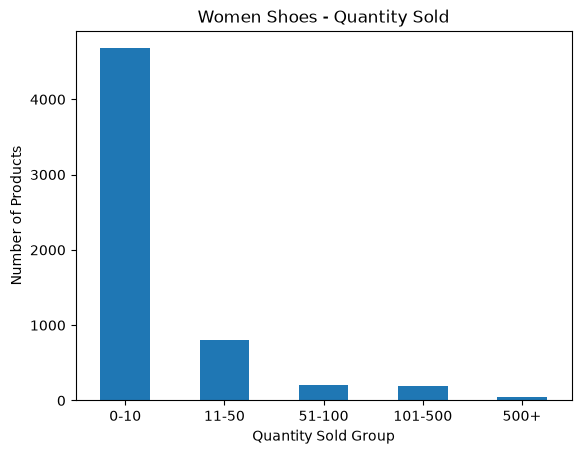

Women shoes: (5917, 27)


,id,name,description,original_price,price,brand,review_count,rating_average,favourite_count,pay_later,...,price_nghin,original_price_nghin,discount_pct,price_normalized,quantity_sold_normalized,review_count_normalized,quantity_sold_group,fulfillment_dropship,fulfillment_seller_delivery,fulfillment_tiki_delivery
0,252071637,"Hộp dép, hộp đựng dép hm - màu cam kich thước ...","Hộp dép, hộp đựng dép hm - màu cam, kích thước...",3000,3000,OEM,0,0.0,0,False,...,3.0,3.0,0.0,0.000545,0.000000,0.000000,0-10,1,0,0
1,208439152,Dép xốp quai ngang đi trong nhà- dép xốp khách...,"Dép xốp quai ngang, đi trong nhà/Khách sạn/Đi ...",14200,14200,OEM,0,0.0,0,False,...,14.2,14.2,0.0,0.002582,0.000000,0.000000,0-10,1,0,0
2,105883794,dép tổ ông huyền thoại,Thiết kế đặc biệtChống trơn trượtKhông ngậm nư...,9900,9900,OEM,3,5.0,0,False,...,9.9,9.9,0.0,0.001800,0.000865,0.005155,0-10,1,0,0
3,252864898,Sen guốc trơn lá lớn_Ảnh thật,"Chào bạn, cảm ơn bạn đã ghé thăm shop ạ Shop...",15000,15000,OEM,0,0.0,0,False,...,15.0,15.0,0.0,0.002727,0.000000,0.000000,0-10,1,0,0
4,252865522,Cây guốc sao trơn,Cây hawothia guốc sao trơn cây đang con Cây ...,13000,13000,OEM,0,0.0,0,False,...,13.0,13.0,0.0,0.002364,0.000000,0.000000,0-10,1,0,0


In [42]:
df["price"] = df["price"].astype(int)  # mẫu bước 2
# TODO: ép các cột số còn lại (như bộ nam)
df["original_price"] = df["original_price"].astype(int)
df["quantity_sold"] = df["quantity_sold"].astype(int)
df["review_count"] = df["review_count"].astype(int)

# TODO: original_price_nghin và discount_pct
df["price_nghin"] = df["price"] / 1000
df["original_price_nghin"] = df["original_price"] / 1000
df["discount_pct"] = (1 - df["price"] / df["original_price"]) * 100
# TODO: normalize quantity_sold và review_count
df["price_normalized"] = df["price"] / df["price"].max()
df["quantity_sold_normalized"] = df["quantity_sold"] / df["quantity_sold"].max()
df["review_count_normalized"] = df["review_count"] / df["review_count"].max()
# TODO: bước 5 — pd.cut + value_counts + plot (copy mẫu bộ nam, đổi title Women)
bins = [-1, 10, 50, 100, 500, float("inf")]
labels = ["0-10", "11-50", "51-100", "101-500", "500+"]

df["quantity_sold_group"] = pd.cut(
    df["quantity_sold"],
    bins=bins,
    labels=labels
)

print(df["quantity_sold_group"].value_counts().sort_index())

df["quantity_sold_group"].value_counts().sort_index().plot(kind="bar")
plt.title("Women Shoes - Quantity Sold")
plt.xlabel("Quantity Sold Group")
plt.ylabel("Number of Products")
plt.xticks(rotation=0)
plt.show()
dummy_ff = pd.get_dummies(df["fulfillment_type"], prefix="fulfillment", dtype=int)  # mẫu bước 6
# TODO: concat + drop fulfillment_type
df = pd.concat([df, dummy_ff], axis=1)
df = df.drop(columns=["fulfillment_type"])
# TODO: to_csv tiki_women_shoes_clean.csv; print shape; df.head()
df.to_csv("tiki_data/tiki_women_shoes_clean.csv", index=False)

print("Women shoes:", df.shape)
df.head()